In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore


In [2]:

df = pd.read_csv("../data/sierraleone-bumbuna.csv")
df

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-10-30 00:01,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.1,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
1,2021-10-30 00:02,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
2,2021-10-30 00:03,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
3,2021-10-30 00:04,-0.7,0.0,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.1,22.3,22.6,NaN
4,2021-10-30 00:05,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525595,2022-10-29 23:56,-1.6,-0.1,-2.9,0.0,0.0,24.0,100.0,0.0,0.0,0.0,0.0,0.0,999,0,0.0,24.2,24.5,NaN
525596,2022-10-29 23:57,-1.7,-0.1,-3.0,0.0,0.0,24.0,100.0,0.0,0.0,0.0,0.0,0.0,999,0,0.0,24.2,24.5,NaN
525597,2022-10-29 23:58,-1.7,-0.1,-3.1,0.0,0.0,24.0,100.0,0.0,0.0,0.0,0.0,0.0,1000,0,0.0,24.1,24.4,NaN
525598,2022-10-29 23:59,-1.7,-0.2,-3.3,0.0,0.0,23.9,100.0,0.0,0.0,0.0,0.0,0.0,1000,0,0.0,24.1,24.4,NaN


In [3]:
df.describe()
df.isna().sum()
df.isna().mean() * 100  # % of missing values

Timestamp          0.0
GHI                0.0
DNI                0.0
DHI                0.0
ModA               0.0
ModB               0.0
Tamb               0.0
RH                 0.0
WS                 0.0
WSgust             0.0
WSstdev            0.0
WD                 0.0
WDstdev            0.0
BP                 0.0
Cleaning           0.0
Precipitation      0.0
TModA              0.0
TModB              0.0
Comments         100.0
dtype: float64

In [4]:
# Columns to check
cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

# Z-score for each column
z_scores = df[cols].apply(zscore)

# Flag extreme outliers
outliers = (np.abs(z_scores) > 3).any(axis=1)
df[outliers]  # View outlier rows

# Drop or Impute
df_clean = df.copy()
df_clean[cols] = df_clean[cols].fillna(df_clean[cols].median())

In [5]:
df_clean.to_csv("../data/sierraleone-bumbuna_clean.csv", index=False)

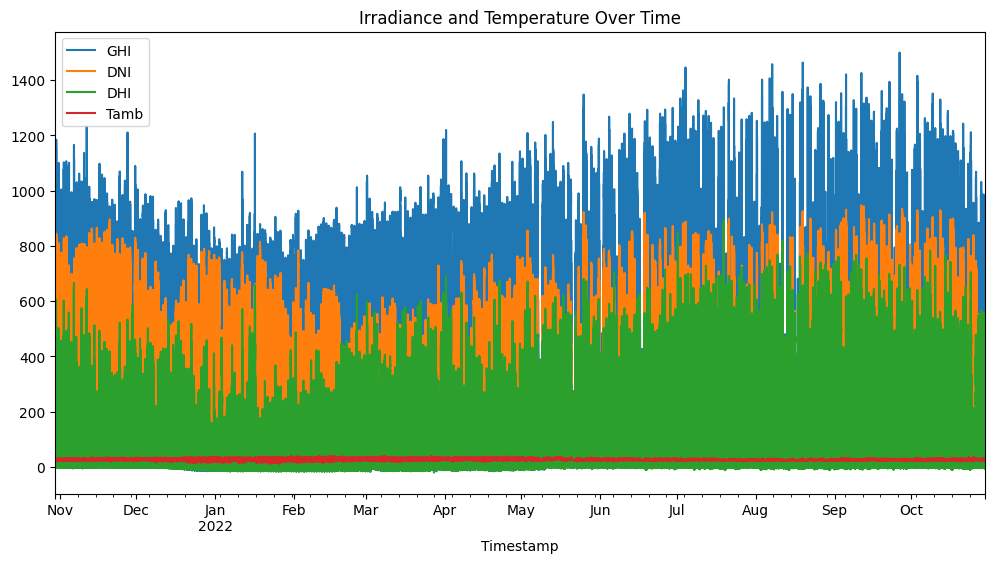

In [6]:
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])

# Plot irradiance and temperature over time
df_clean.plot(x='Timestamp', y=['GHI', 'DNI', 'DHI', 'Tamb'], figsize=(12, 6))
plt.title('Irradiance and Temperature Over Time')
plt.show()

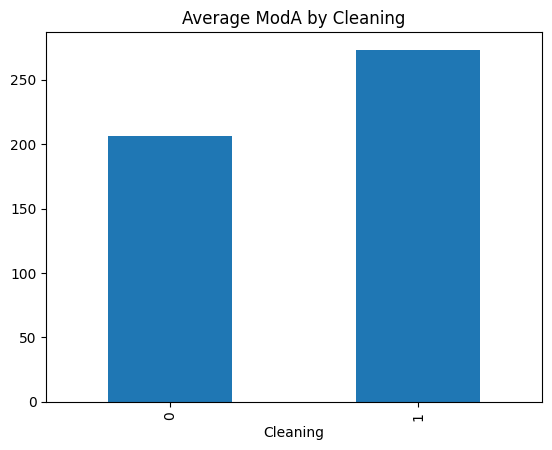

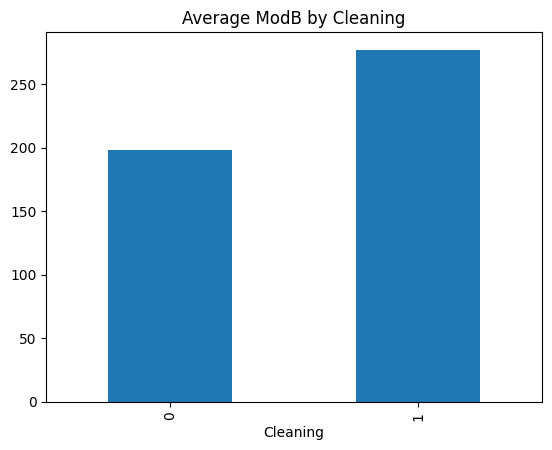

In [7]:
df_clean.groupby('Cleaning')['ModA'].mean().plot(kind='bar')
plt.title('Average ModA by Cleaning')
plt.show()

df_clean.groupby('Cleaning')['ModB'].mean().plot(kind='bar')
plt.title('Average ModB by Cleaning')
plt.show()

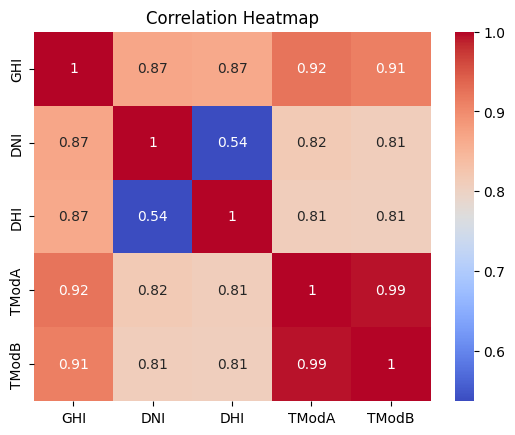

In [8]:
# Correlation heatmap
sns.heatmap(df_clean[['GHI', 'DNI', 'DHI', 'TModA', 'TModB']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

<Axes: xlabel='WS', ylabel='GHI'>

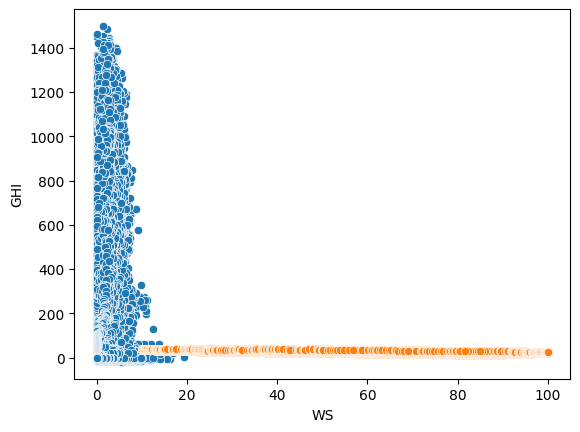

In [9]:
#Scatterplot
sns.scatterplot(x='WS', y='GHI', data=df_clean)
sns.scatterplot(x='RH', y='Tamb', data=df_clean)

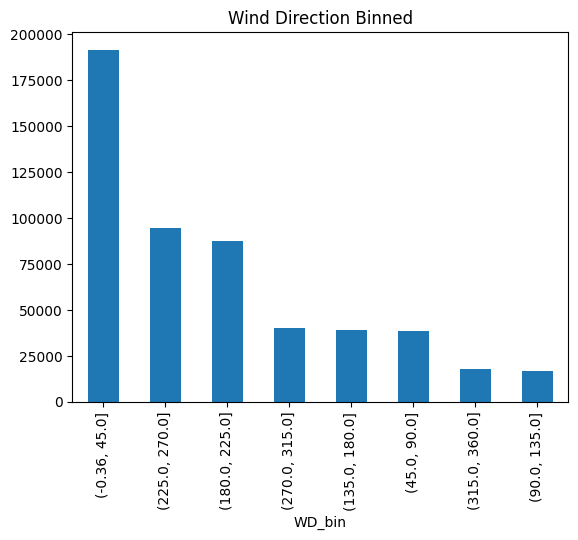

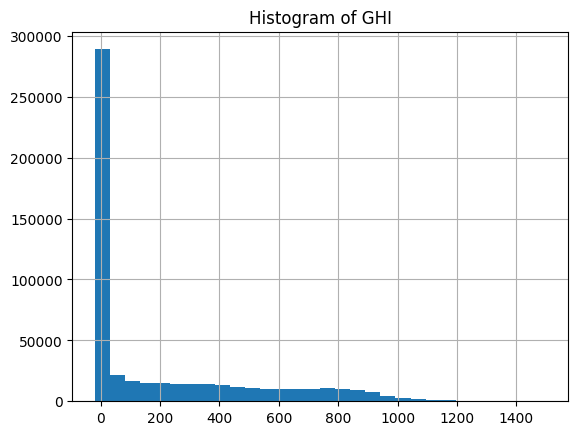

In [10]:
#Wind & Distribution Analysis
df_clean['WD_bin'] = pd.cut(df_clean['WD'], bins=8)  # Bin wind directions
df_clean['WD_bin'].value_counts().plot(kind='bar')
plt.title('Wind Direction Binned')
plt.show()

df_clean['GHI'].hist(bins=30)
plt.title('Histogram of GHI')
plt.show()

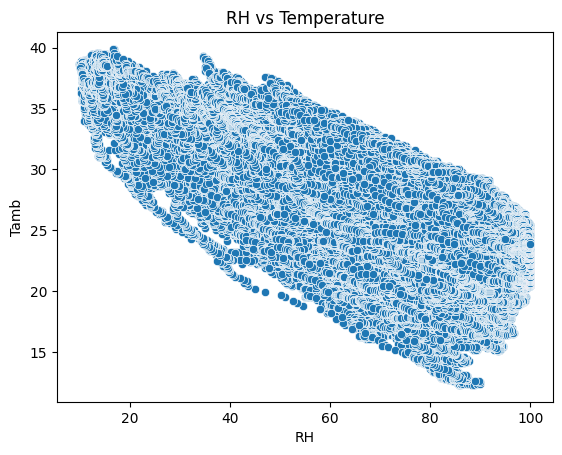

In [11]:
#Temperature & RH
sns.scatterplot(x='RH', y='Tamb', data=df_clean)
plt.title('RH vs Temperature')
plt.show()

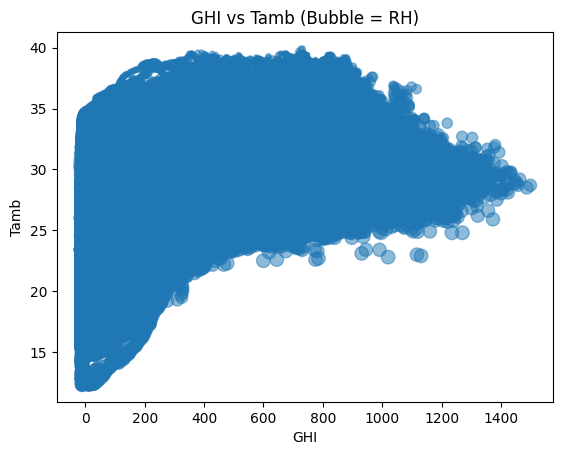

In [12]:
#Bubble Chart
plt.scatter(df_clean['GHI'], df_clean['Tamb'], s=df_clean['RH'], alpha=0.5)
plt.xlabel('GHI')
plt.ylabel('Tamb')
plt.title('GHI vs Tamb (Bubble = RH)')
plt.show()